In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

# Check if we are currently inside the 'notebooks' folder
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [3]:
from src.config import SimConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker, print_markdown_table
from src.utils.plotting import plot_simulation_dashboard, plot_benchmarker_results, plot_markov_matrix

from src.solvers import AugmentedHybridSDPSolver, AugmentedBaselineSDPSolver

from src.plants import AugmentedHybridPlant, AugmentedFuelCellOnlyPlant

from src.controllers import (
    build_approach,
    AugmentedFCLockedControl,
    AugmentedPolicyControl,
    AugmentedValueControl,
    AugmentedSDPBaselineControl
)

config = SimConfig()
fleet_data = load_and_cache_entire_fleet(config)

# Initialize benchmarker
exclude_days = [] 
benchmarker = VoyageBenchmarker(fleet_data, config, exclude_days)


⚙️  EMS Configuration Loaded | Smart Grid: ON
 -> dP Step Size       : 150.0 kW
 -> Grid Dimensions    : N_d≈20, N_n=16, N_soc=25, N_fc=21, N_bat=15
 -> Augmented Space |S|: 168,000 states
 -> Action Space |A|   : 240 actions
 -> Est. Big-O Comput. : O(13,104,000,000) operations
 -> Est. RAM Footprint : ~964.51 MB

Beginning memory staging of all 14 fleet files into RAM...
 -> Day 01 successfully cached in RAM.
 -> Day 02 successfully cached in RAM.
 -> Day 03 successfully cached in RAM.
 -> Day 04 successfully cached in RAM.
 -> Day 05 successfully cached in RAM.
 -> Day 06 successfully cached in RAM.
 -> Day 07 successfully cached in RAM.
 -> Day 08 successfully cached in RAM.
 -> Day 09 successfully cached in RAM.
 -> Day 10 successfully cached in RAM.
 -> Day 11 successfully cached in RAM.
 -> Day 12 successfully cached in RAM.
 -> Day 13 successfully cached in RAM.
 -> Day 14 successfully cached in RAM.

All 14 operational days securely held in RAM. Disk I/O locked.


In [4]:
augmented_approaches = {
    # "MacroFuelCellOnlyBaseline": build_approach(
    #     plant_cls=AugmentedFuelCellOnlyPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=True
    # ),
    # "FuelCellOnlyBaseline": build_approach(
    #     plant_cls=AugmentedFuelCellOnlyPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=False
    # ),
    # "MacroHybridBaseline": build_approach(
    #     plant_cls=AugmentedHybridPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=True
    # ),
    # "HybridBaseline": build_approach(
    #     plant_cls=AugmentedHybridPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=False
    # ),
    "MacroFCLocked": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedFCLockedControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "FCLocked": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedFCLockedControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
    "MacroPolicy": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedPolicyControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "Policy": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedPolicyControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
    "MacroValue": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedValueControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "Value": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedValueControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
}

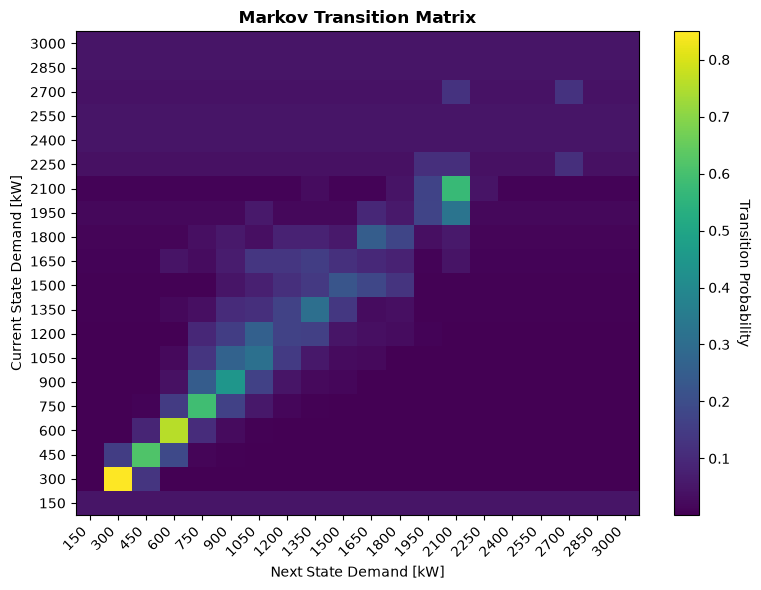

In [5]:
# Manually choose training block and test validation target
train_days = [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14]
mc_model, _, _ = benchmarker._get_or_compute_models(train_days, solver_cls=None, horizon_length=1)
plot_markov_matrix(mc_model)
test_day = 6
approaches = augmented_approaches

--- APPROACH A: HAND-PICKED EVALUATION ---
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
| Strategy      | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Transient Cost [$] | Term. Switch Cost [$] | Term. SoC Cost [$] | Offline Compute Time [s] | Online Compute Time [s] |
|---------------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| MacroFCLocked | 5446.12        | 5182.60            | 155.90             | 36.47            | 61.61              | 16.13                 | -6.59              | 202.70                   | 0.10                    |
| FCLocked      | 6292.04        | 5208.66            | 185.47             | 40.62            | 863.43             | 18.82                 | -24.95             | 202.70                   | 0.50                    |
| MacroPolicy   |

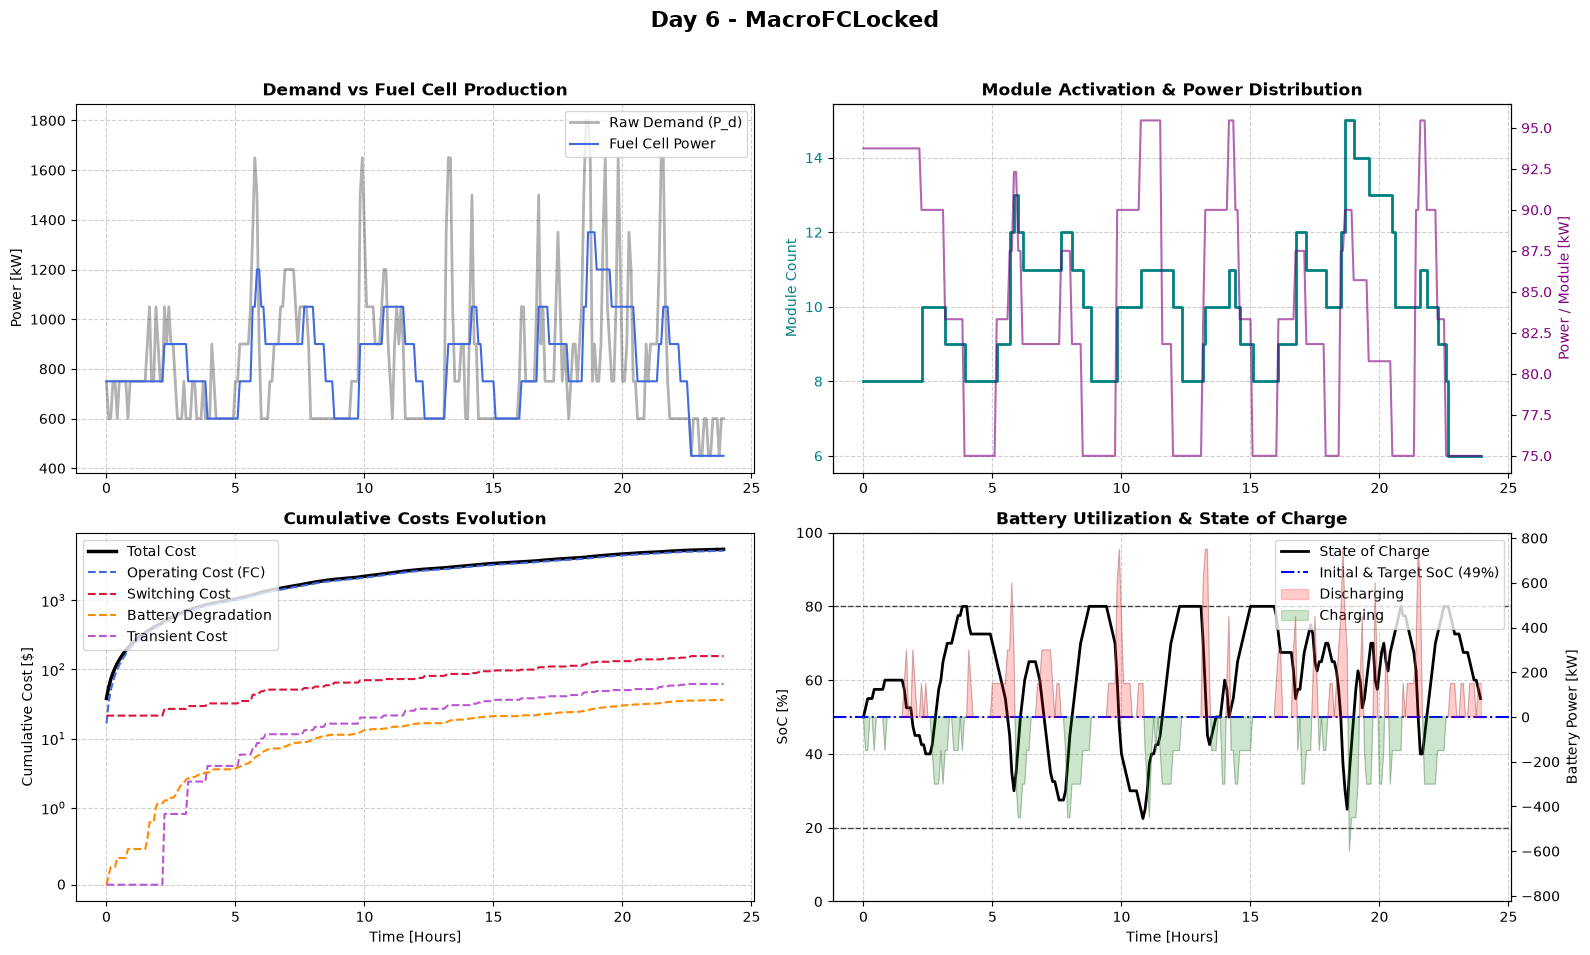

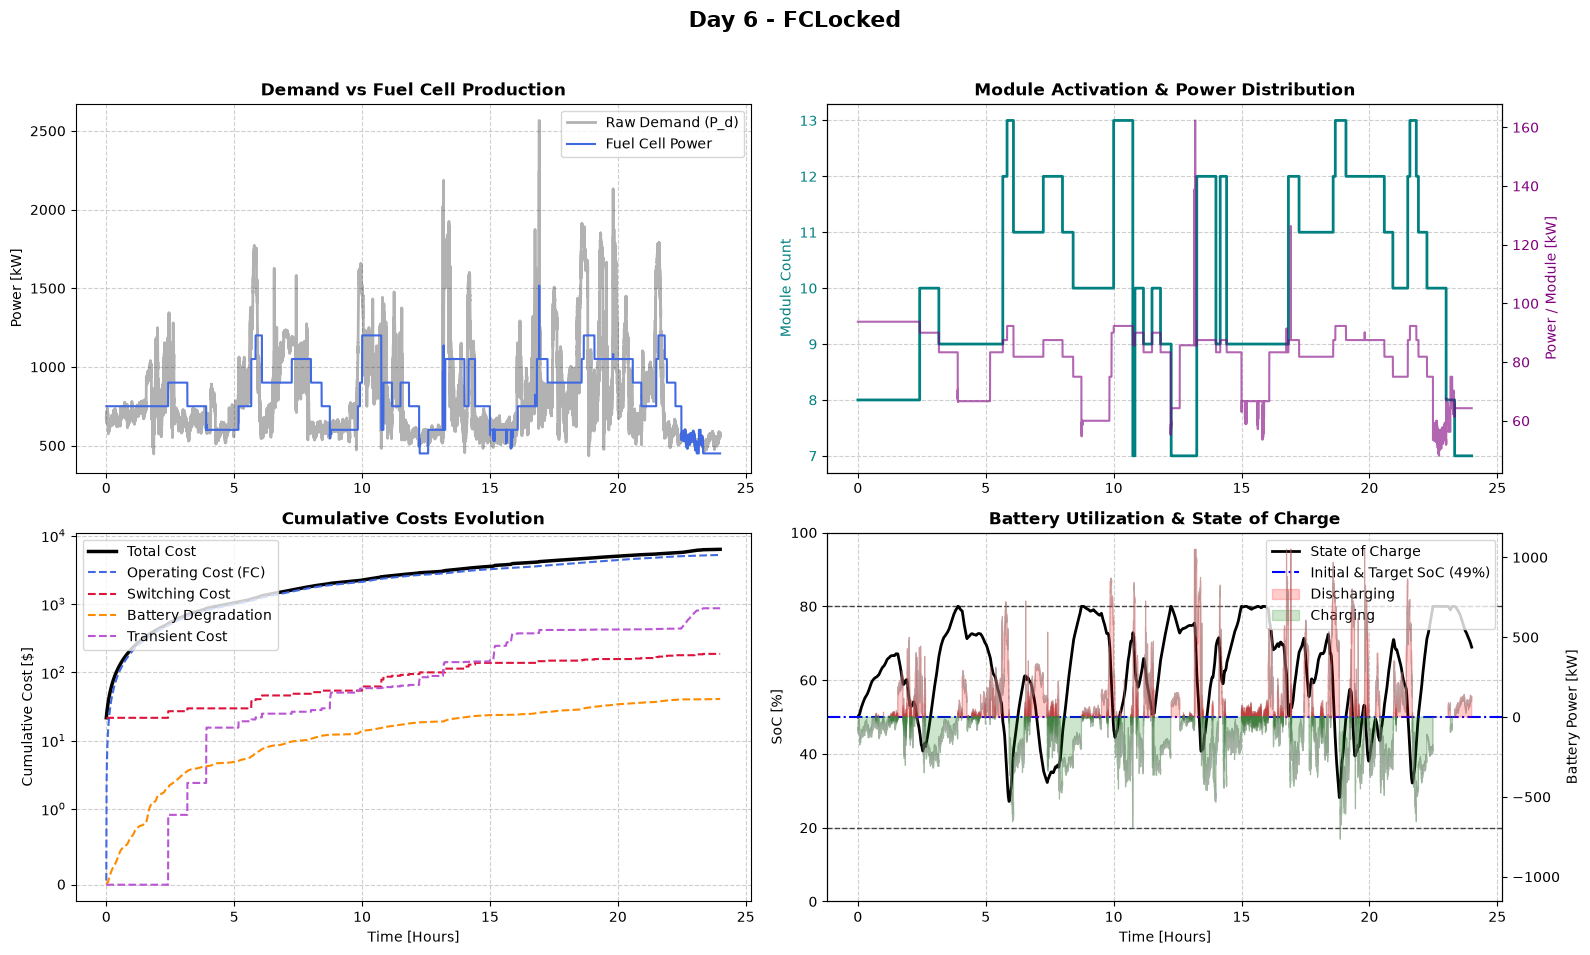

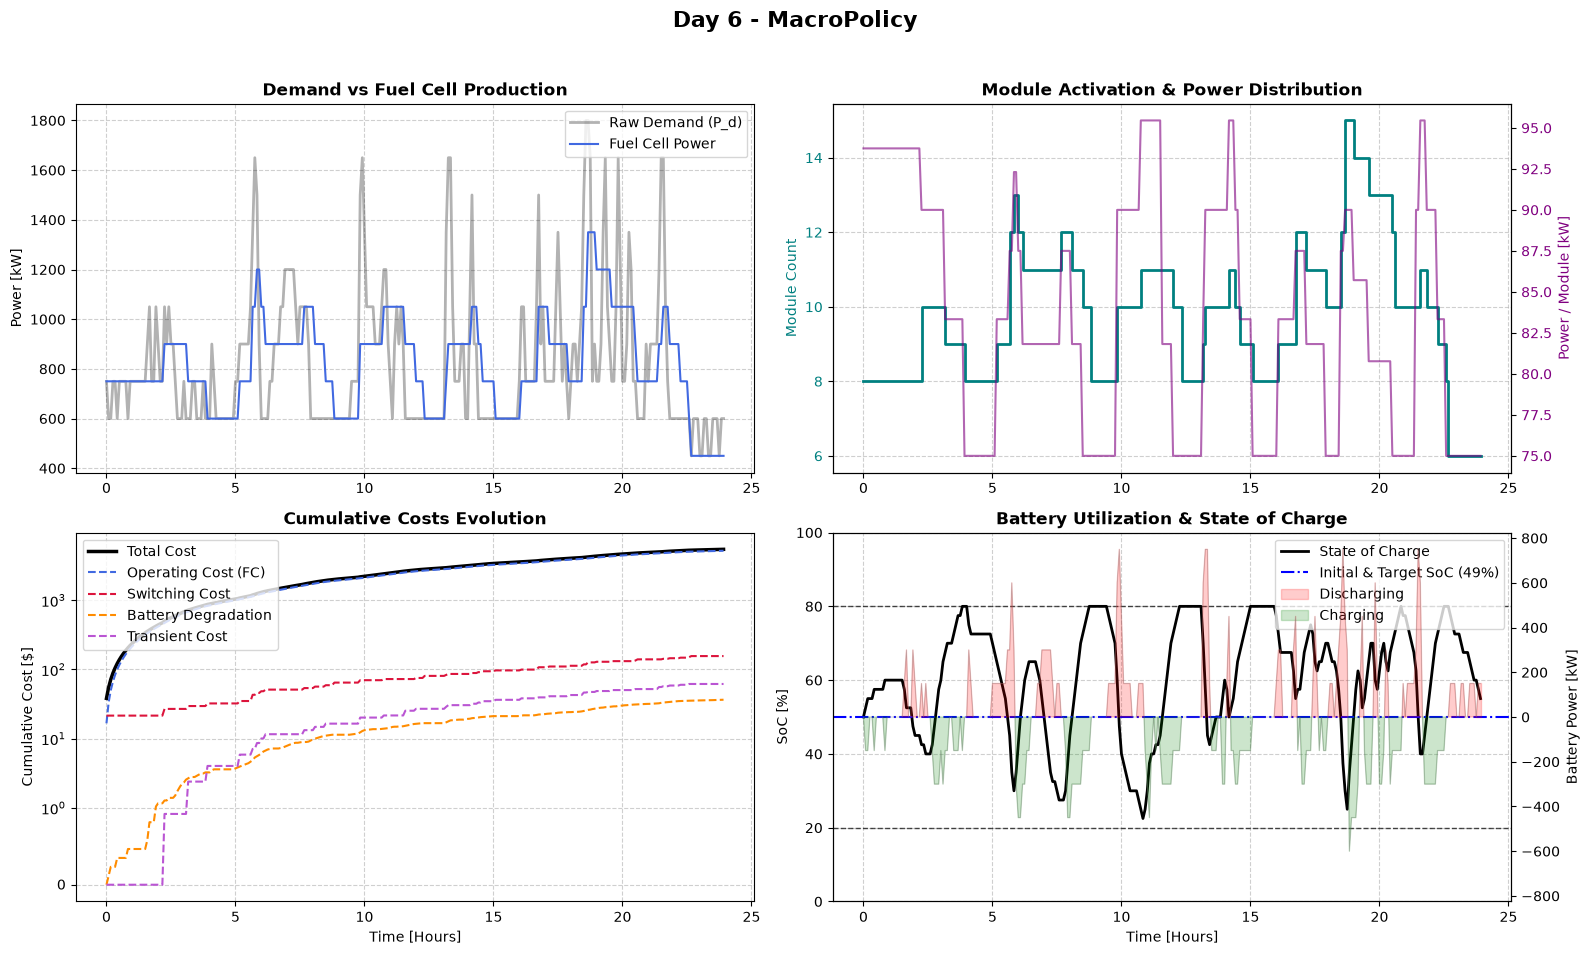

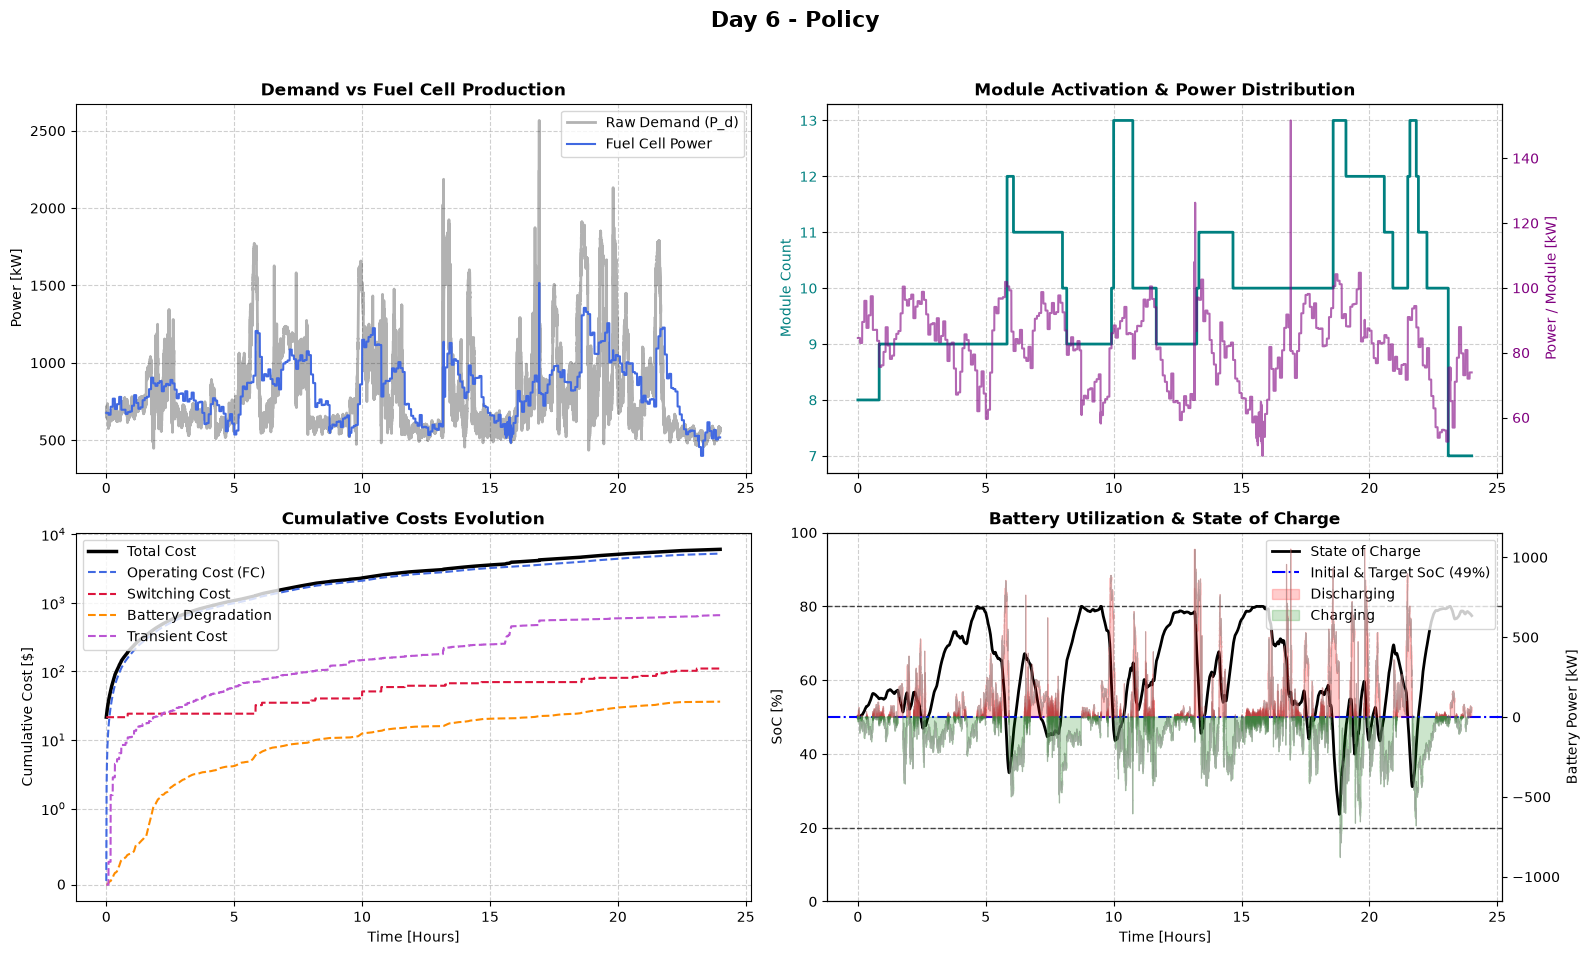

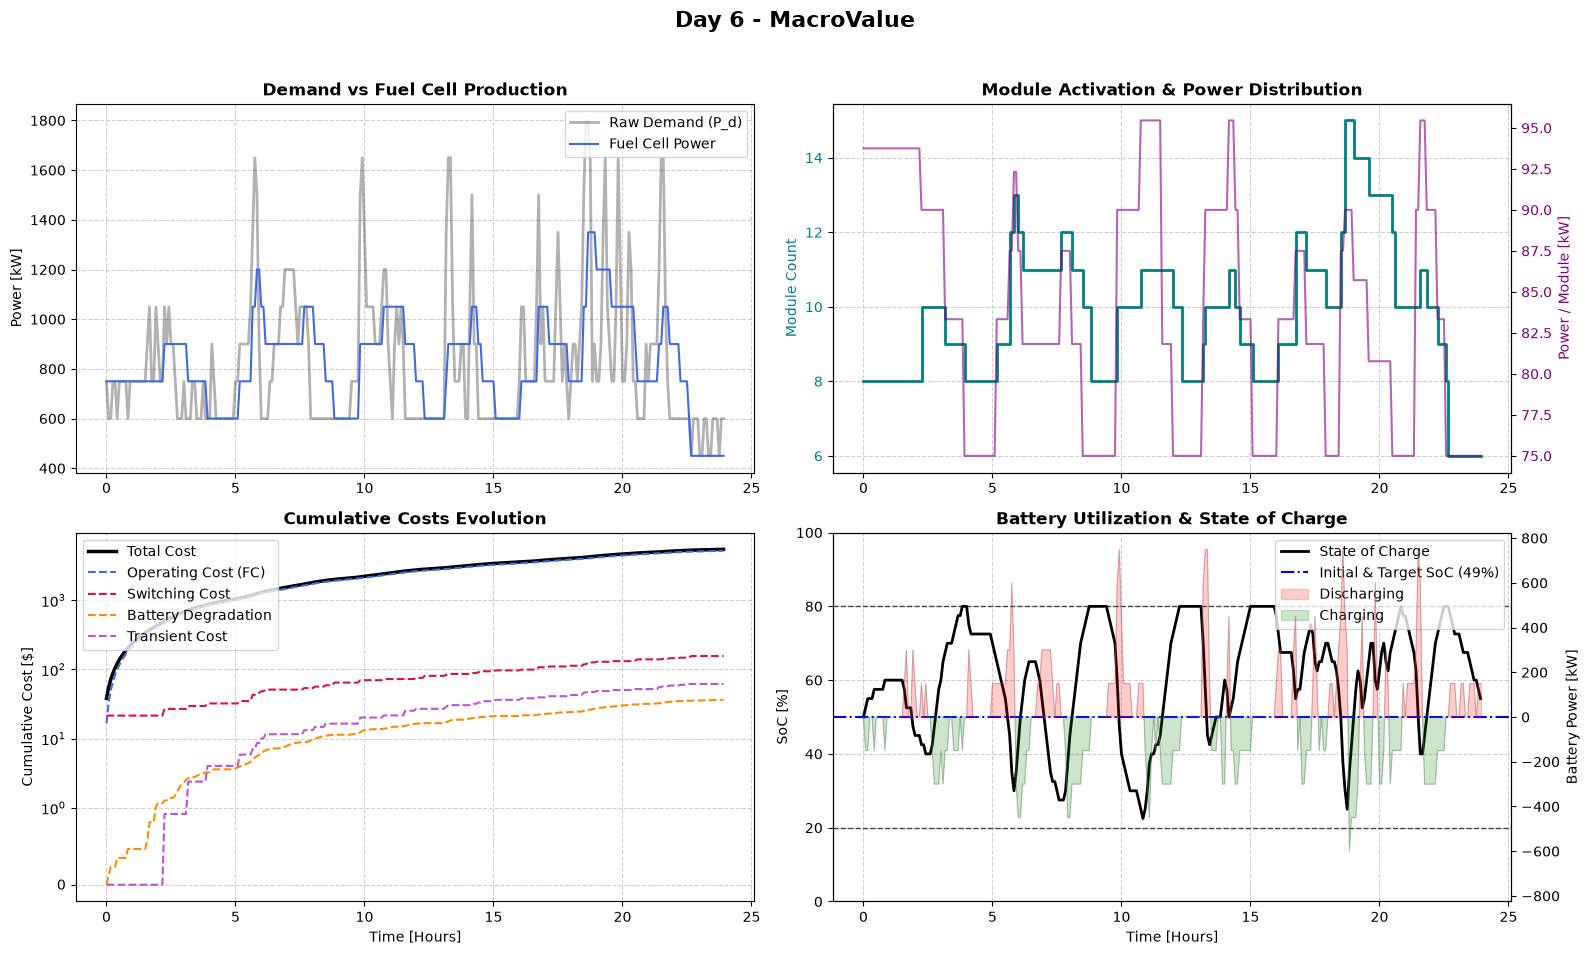

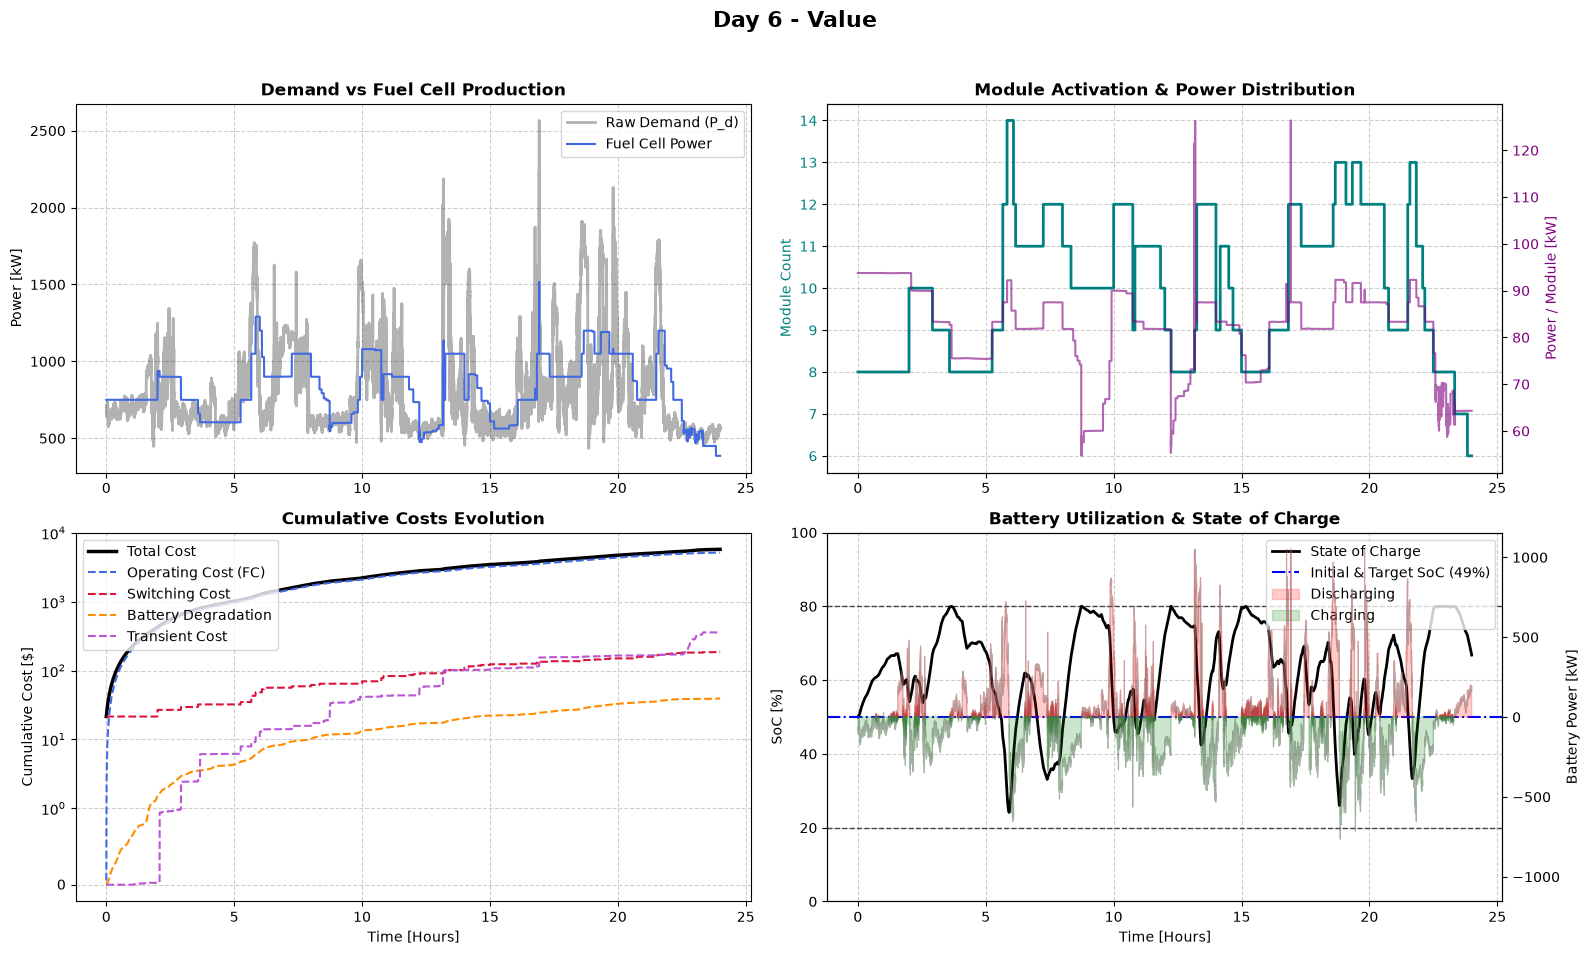

In [6]:
print("--- APPROACH A: HAND-PICKED EVALUATION ---")

report = benchmarker.compare_approaches(approaches, train_days, test_day)
print_markdown_table(report.summary)

for app in approaches:
    plot_simulation_dashboard(report.get_telemetry(app), benchmarker.config, title=f"Day {test_day} - {app}", indiv=False)



In [ ]:
print("\n--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---")

# Note: Running LOO on all 5 approaches might take a couple of minutes due to 4D solves.
# Let's compare the main engineering deployable hybrid against the legacy baseline.

for app in approaches:
# for app in ["Value"]:
    report = benchmarker.run_leave_one_out(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Leave-One-Out Cross Validation ({app})", plot_type='bar')
    print_markdown_table(report.summary)



In [ ]:
print("\n--- APPROACH C: FORWARD CHAINING (Learning Curve) ---")
# Evaluate how the policy improves as the agent gathers chronological data
# Using the Lookahead Optimum to see the absolute theoretical ceiling of the ship's capabilities

for app in approaches:
# for app in ["Value"]:
    report = benchmarker.run_forward_chaining(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Forward Chaining Learning Curve ({app})", plot_type='line')
    print_markdown_table(report.summary)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

p_max = 200 #kW
p_nom = 80 #kW
LHV = 120 #kJ/g
eta_max = 0.6
eta_f = 0.5

alpha = p_max / (p_max - p_nom)**2 * (1/eta_f - 1/eta_max)
beta = 1/eta_max - 2*alpha*p_nom 
gamma = alpha * p_nom ** 2

a, b, c = alpha / LHV, beta / LHV, gamma / LHV

p_vec = np.linspace(0, p_max, 100)
plt.plot(p_vec, a*p_vec**2 + b*p_vec + c)
plt.plot(p_vec, p_vec/(a*p_vec**2 + b*p_vec + c)/LHV)